# Dataset Explorer: GoEmotions + Financial PhraseBank

**Project:** Domain-Adaptive Sentiment Analysis using Transformers and LLMs
**Datasets:**
- **General-Domain:** GoEmotions (58k Reddit comments, 27 emotion labels).
- **Domain-Specific:** Financial PhraseBank (4,845 financial news sentences).

Load both datasets, explore their structure, maps GoEmotions to a 3-class financial sentiment scheme, and performs cross-domain EDA.

## 1. Setup & Installation.

Run the cell below once to install the required libraries.

In [1]:
pip install datasets pandas matplotlib seaborn wordcloud -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'datasets==2.21.0', 'pandas', 'matplotlib', 'seaborn', 'wordcloud', '-q'])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('All imports loaded successfully.')

C:\Users\vikra\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports loaded successfully.


# Part A: Financial PhraseBank (Domain-Specific Dataset).

The Financial PhraseBank dataset contains 4,845 sentences from English financial news, annotated by 16 finance professionals as **Positive**, **Negative**, or **Neutral** from an investor's viewpoint.

The `takala` version on HuggingFace provides 4 subsets based on annotator agreement:
- `sentences_50agree` - 4,846 samples (lowest threshold, largest set).
- `sentences_66agree` - 4,217 samples.
- `sentences_75agree` - 3,453 samples.
- `sentences_allagree` - 2,264 samples (100% consensus, smallest but cleanest).

### A1. Load the dataset.

In [3]:
# Load with 50% agreement (largest subset).
# will Change to 'sentences_66agree', 'sentences_75agree', or 'sentences_allagree' as needed.
fpb = load_dataset('takala/financial_phrasebank', 'sentences_50agree', trust_remote_code=True)

# Convert to pandas.
fpb_df = pd.DataFrame(fpb['train'])
fpb_df.columns = ['sentence', 'label']

# Map numeric labels to readable text.
fpb_label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
fpb_df['sentiment'] = fpb_df['label'].map(fpb_label_map)

print(f'Total samples: {len(fpb_df)}')
print(f'Columns: {list(fpb_df.columns)}')
fpb_df.head()

Total samples: 4846
Columns: ['sentence', 'label', 'sentiment']


,sentence,label,sentiment
0,"According to Gran , the company has no plans t...",1,Neutral
1,Technopolis plans to develop in stages an area...,1,Neutral
2,The international electronic industry company ...,0,Negative
3,With the new production plant the company woul...,2,Positive
4,According to the company 's updated strategy f...,2,Positive


### A2. Class distribution.

In [4]:
print('class distribution:')
print(fpb_df['sentiment'].value_counts())
print(f'\nPercentages:')
print((fpb_df['sentiment'].value_counts(normalize=True) * 100).round(1))


class distribution:
sentiment
Neutral     2879
Positive    1363
Negative     604
Name: count, dtype: int64

Percentages:
sentiment
Neutral     59.4
Positive    28.1
Negative    12.5
Name: proportion, dtype: float64


### A3. Text length analysis.
(text length is important for tokenisation and padding strategies)

In [5]:
fpb_df['word_count'] = fpb_df['sentence'].apply(lambda x: len(x.split()))
fpb_df['char_count'] = fpb_df['sentence'].apply(len)

print('Text Length Statistics:')
fpb_df[['word_count', 'char_count']].describe().round(1)

Text Length Statistics:


,word_count,char_count
count,4846.0,4846.0
mean,23.1,128.1
std,10.0,56.5
min,2.0,9.0
25%,16.0,84.0
50%,21.0,119.0
75%,29.0,163.0
max,81.0,315.0


### A4. Visualise Financial PhraseBank.

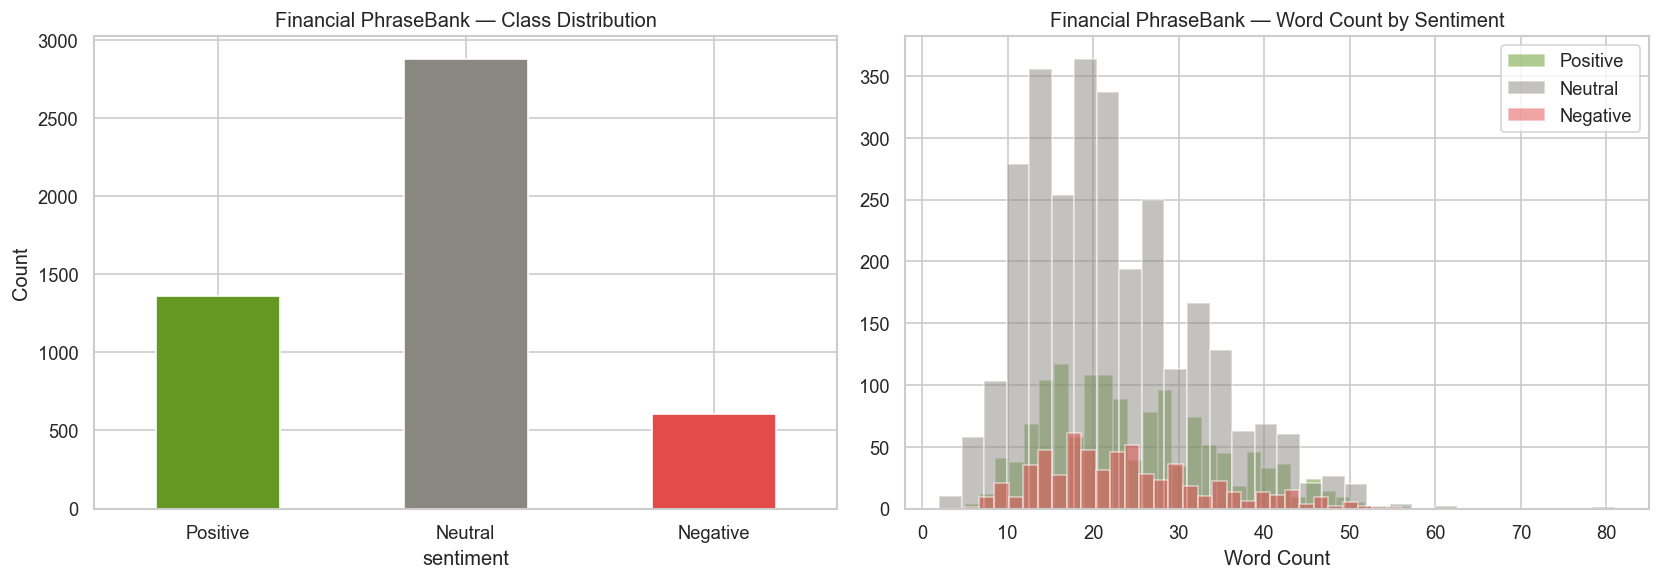

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution bar chart
colors = {'Negative': '#E24B4A', 'Neutral': '#888780', 'Positive': '#639922'}
order = ['Positive', 'Neutral', 'Negative']
fpb_df['sentiment'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=[colors[s] for s in order])
axes[0].set_title('Financial PhraseBank — Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Text length by sentiment.
for sentiment in order:
    subset = fpb_df[fpb_df['sentiment'] == sentiment]
    axes[1].hist(subset['word_count'], bins=30, alpha=0.5, label=sentiment, color=colors[sentiment])
axes[1].set_title('Financial PhraseBank — Word Count by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### A5. Compare agreement levels.
how does the class distribution shift when we require higher annotator consensus?.

In [7]:
agreement_data = []
for config in ['sentences_50agree', 'sentences_66agree', 'sentences_75agree', 'sentences_allagree']:
    ds = load_dataset('takala/financial_phrasebank', config, trust_remote_code=True)
    df_temp = pd.DataFrame(ds['train'])
    df_temp.columns = ['sentence', 'label']
    df_temp['sentiment'] = df_temp['label'].map(fpb_label_map)
    counts = df_temp['sentiment'].value_counts()
    agreement_data.append({
        'Agreement': config.replace('sentences_', '').replace('agree', '% agree'),
        'Total': len(df_temp),
        'Positive': counts.get('Positive', 0),
        'Neutral': counts.get('Neutral', 0),
        'Negative': counts.get('Negative', 0)
    })

agreement_df = pd.DataFrame(agreement_data)
print('Agreement Level Comparison:')
agreement_df

Agreement Level Comparison:


,Agreement,Total,Positive,Neutral,Negative
0,50% agree,4846,1363,2879,604
1,66% agree,4217,1168,2535,514
2,75% agree,3453,887,2146,420
3,all% agree,2264,570,1391,303



# Part B: GoEmotions (General-Domain Dataset).

GoEmotions (Demszky et al., ACL 2020) is a dataset of 58k Reddit comments labelled for **27 emotion categories + Neutral**. It is multi-label, a single comment can be tagged with multiple emotions.

This will serve as our **general-domain** dataset. We'll later map the 28 labels down to 6 classes to align with the financial sentiment task.

### B1. Load the dataset.

In [8]:
goemotions = load_dataset('google-research-datasets/go_emotions', 'simplified')

ge_train = pd.DataFrame(goemotions['train'])
ge_val = pd.DataFrame(goemotions['validation'])
ge_test = pd.DataFrame(goemotions['test'])

print(f'Train:      {len(ge_train)} samples')
print(f'Validation: {len(ge_val)} samples')
print(f'Test:       {len(ge_test)} samples')
print(f'Total:      {len(ge_train) + len(ge_val) + len(ge_test)} samples')
print(f'\nColumns: {list(ge_train.columns)}')
ge_train.head()

Train:      43410 samples
Validation: 5426 samples
Test:       5427 samples
Total:      54263 samples

Columns: ['text', 'labels', 'id']


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


### B2. Explore the emotion labels.
Each sample has a list of label IDs. Let's see what they are and how often each appears.

In [9]:
emotion_labels = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
]

print('All Labels:')
for i, label in enumerate(emotion_labels):
    print(f'  {i:2d}: {label}')

All Labels:
   0: admiration
   1: amusement
   2: anger
   3: annoyance
   4: approval
   5: caring
   6: confusion
   7: curiosity
   8: desire
   9: disappointment
  10: disapproval
  11: disgust
  12: embarrassment
  13: excitement
  14: fear
  15: gratitude
  16: grief
  17: joy
  18: love
  19: nervousness
  20: optimism
  21: pride
  22: realization
  23: relief
  24: remorse
  25: sadness
  26: surprise
  27: neutral


In [10]:
# Count label frequencies across all training samples.
all_labels = []
for label_list in ge_train['labels']:
    all_labels.extend(label_list)

label_counts = Counter(all_labels)
label_freq = pd.DataFrame([
    {'emotion': emotion_labels[k], 'count': v}
    for k, v in label_counts.items()
]).sort_values('count', ascending=False).reset_index(drop=True)

print('Label Frequencies (all 28):')
label_freq

Label Frequencies (all 28):


,emotion,count
0,neutral,14219
1,admiration,4130
2,approval,2939
3,gratitude,2662
4,annoyance,2470
5,amusement,2328
6,curiosity,2191
7,love,2086
8,disapproval,2022
9,optimism,1581


### B3. Visualise GoEmotions label distribution

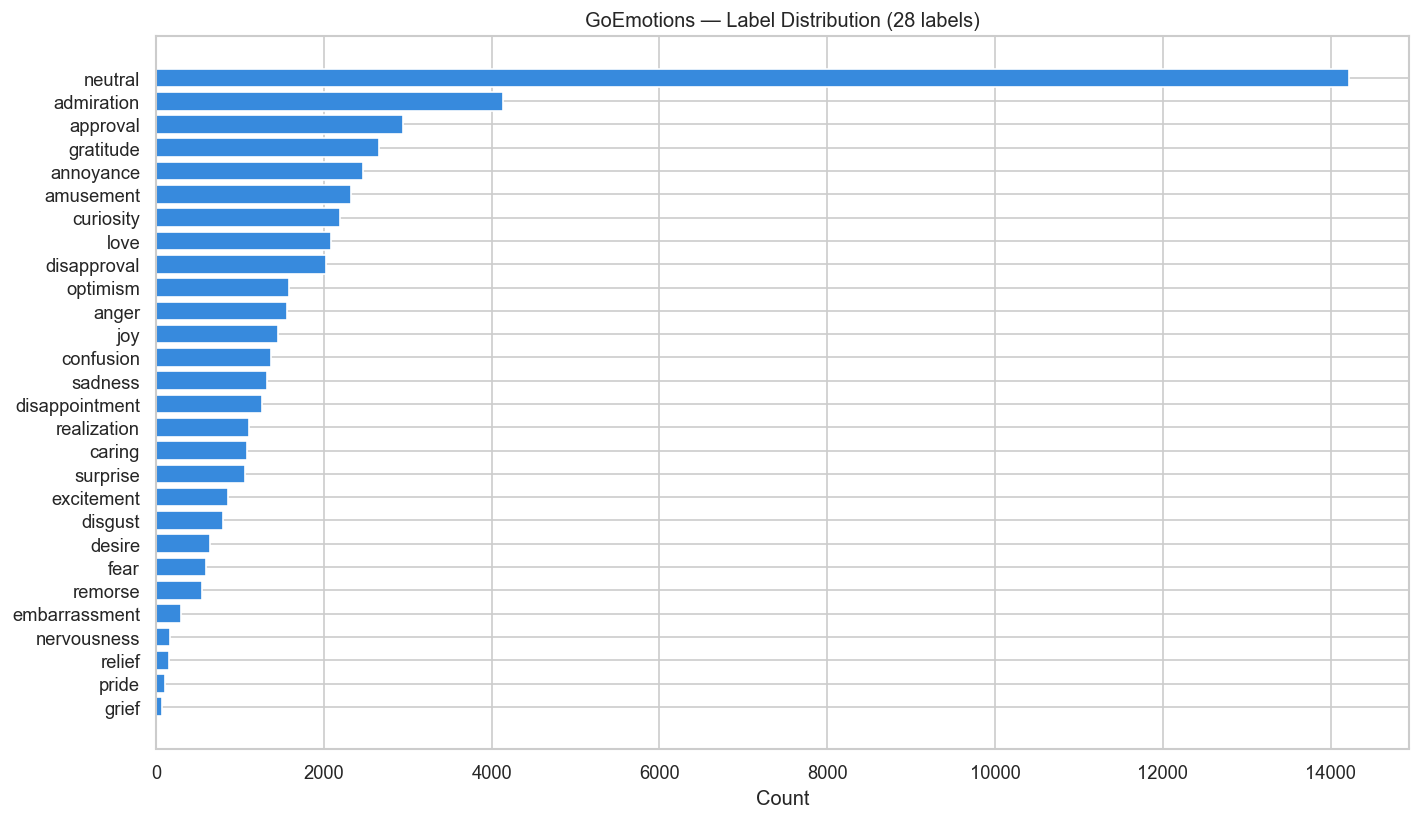

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(label_freq['emotion'], label_freq['count'], color='#378ADD')
ax.set_xlabel('Count')
ax.set_title('GoEmotions — Label Distribution (28 labels)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### B4. Text length analysis.

In [12]:
ge_train['word_count'] = ge_train['text'].apply(lambda x: len(x.split()))
ge_train['char_count'] = ge_train['text'].apply(len)

print('GoEmotions Text Length Statistics:')
ge_train[['word_count', 'char_count']].describe().round(1)

GoEmotions Text Length Statistics:


,word_count,char_count
count,43410.0,43410.0
mean,12.8,68.4
std,6.7,36.7
min,1.0,2.0
25%,7.0,38.0
50%,12.0,65.0
75%,18.0,96.0
max,33.0,703.0


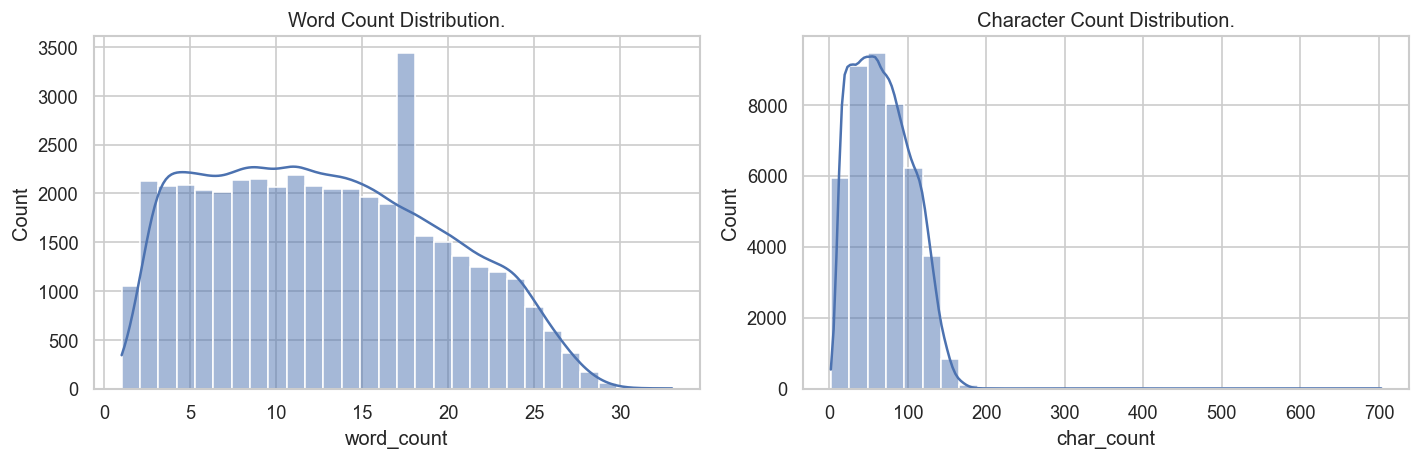

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ge_train['word_count'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Word Count Distribution.')
sns.histplot(ge_train['char_count'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Character Count Distribution.')
plt.tight_layout()
plt.show()




### B5. Multi-label analysis.

How many emotions are typically assigned per comment?.

In [14]:
ge_train['num_labels'] = ge_train['labels'].apply(len)

print('Labels per sample:')
print(ge_train['num_labels'].value_counts().sort_index())
print(f'\nAverage labels per sample: {ge_train["num_labels"].mean():.2f}')

Labels per sample:
num_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64

Average labels per sample: 1.18


# Part C: Label Mapping - GoEmotions - 3-Class Financial Sentiment. 
Note: this is (Experimental labels maping on orginal dataset to see 3-class distribution side by side, we will map 6-class sentiment for  both data sets on part F, later on.)

 We need to map GoEmotions' 27 emotion categories into 3 classes that align with financial sentiment:

| Target Class | Mapped GoEmotions Labels |
|---|---|
| **Bullish** (Positive) | admiration, amusement, approval, caring, desire, excitement, gratitude, joy, love, optimism, pride, relief |
| **Bearish** (Negative) | anger, annoyance, disappointment, disapproval, disgust, embarrassment, fear, grief, nervousness, remorse, sadness |
| **Neutral** | confusion, curiosity, realization, surprise, neutral |



### C1. Define the mapping and apply it.

In [15]:
label_mapping = {
    # Bullish (positive / optimistic emotions)
    'admiration': 'Bullish', 'amusement': 'Bullish', 'approval': 'Bullish',
    'caring': 'Bullish', 'desire': 'Bullish', 'excitement': 'Bullish',
    'gratitude': 'Bullish', 'joy': 'Bullish', 'love': 'Bullish',
    'optimism': 'Bullish', 'pride': 'Bullish', 'relief': 'Bullish',
    
    # Bearish (negative / fear / risk emotions)
    'anger': 'Bearish', 'annoyance': 'Bearish', 'disappointment': 'Bearish',
    'disapproval': 'Bearish', 'disgust': 'Bearish', 'embarrassment': 'Bearish',
    'fear': 'Bearish', 'grief': 'Bearish', 'nervousness': 'Bearish',
    'remorse': 'Bearish', 'sadness': 'Bearish',
    
    # Neutral / Ambiguous
    'confusion': 'Neutral', 'curiosity': 'Neutral', 'realization': 'Neutral',
    'surprise': 'Neutral', 'neutral': 'Neutral',
}

def map_to_3class(label_ids):
    """Map multi-label emotions to a single 3-class label.
    Takes majority vote. Defaults to Neutral on ties."""
    mapped = [label_mapping[emotion_labels[lid]] for lid in label_ids]
    counts = Counter(mapped)
    return counts.most_common(1)[0][0]

ge_train['sentiment_3class'] = ge_train['labels'].apply(map_to_3class)

print('GoEmotions — Mapped 3-Class Distribution:')
print(ge_train['sentiment_3class'].value_counts())
print(f'\nPercentages:')
print((ge_train['sentiment_3class'].value_counts(normalize=True) * 100).round(1))

GoEmotions — Mapped 3-Class Distribution:
sentiment_3class
Neutral    17311
Bullish    16929
Bearish     9170
Name: count, dtype: int64

Percentages:
sentiment_3class
Neutral    39.9
Bullish    39.0
Bearish    21.1
Name: proportion, dtype: float64


### C2. Compare class distributions side by side.

Clolor codes: {'Bullish': '#639922', 'Neutral': '#888780', 'Bearish': '#E24B4A'}

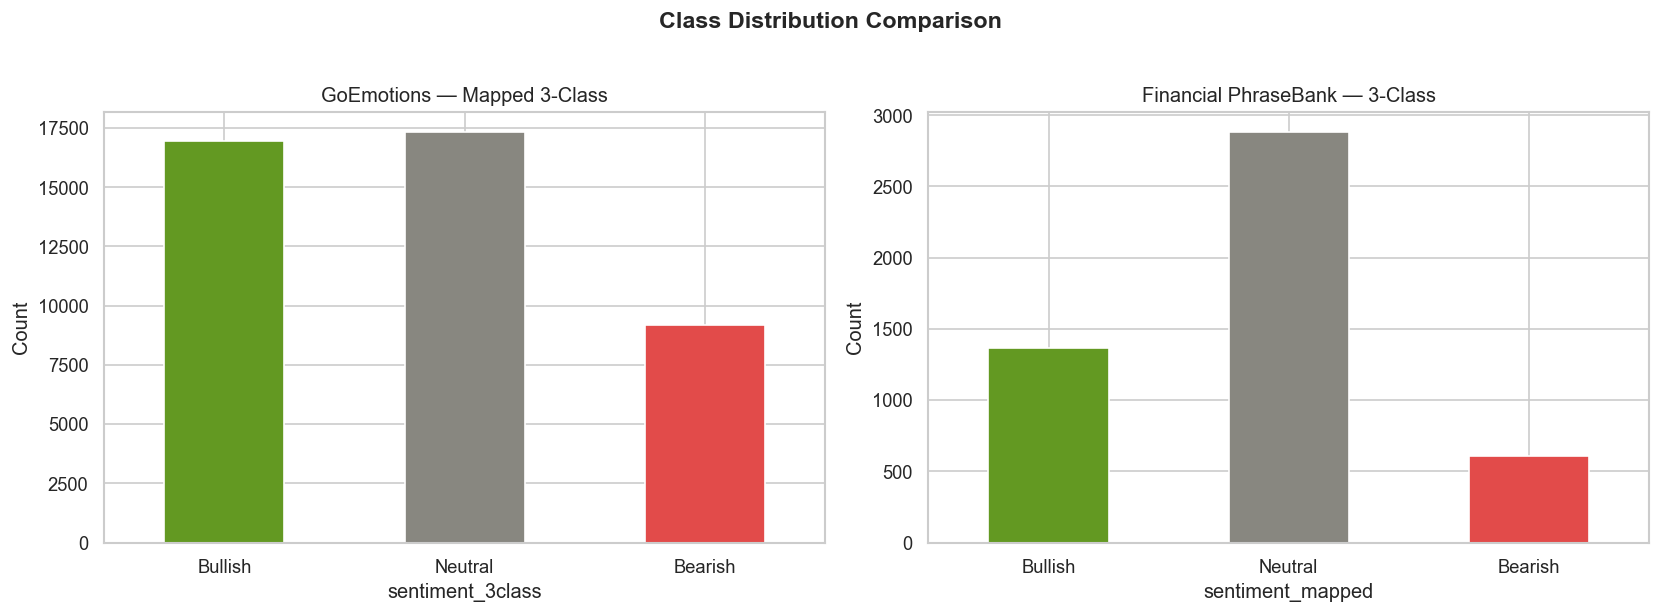

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_3class = {'Bullish': '#639922', 'Neutral': '#888780', 'Bearish': '#E24B4A'}
order_3class = ['Bullish', 'Neutral', 'Bearish']

# GoEmotions mapped
ge_counts = ge_train['sentiment_3class'].value_counts().reindex(order_3class)
ge_counts.plot(kind='bar', ax=axes[0], color=[colors_3class[s] for s in order_3class])
axes[0].set_title('GoEmotions — Mapped 3-Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Financial PhraseBank (map labels to match)
fpb_map = {'Positive': 'Bullish', 'Neutral': 'Neutral', 'Negative': 'Bearish'}
fpb_df['sentiment_mapped'] = fpb_df['sentiment'].map(fpb_map)
fpb_counts = fpb_df['sentiment_mapped'].value_counts().reindex(order_3class)
fpb_counts.plot(kind='bar', ax=axes[1], color=[colors_3class[s] for s in order_3class])
axes[1].set_title('Financial PhraseBank — 3-Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Class Distribution Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Part D: Cross-Domain EDA.

This section compares the two datasets to quantify the **domain gap**  the distributional differences that make cross-domain sentiment analysis challenging.

### D1. Dataset size comparison.

In [17]:
print('Dataset Size Comparison')
print('=' * 45)
print(f'GoEmotions (general):          {len(ge_train):,} samples')
print(f'Financial PhraseBank (domain):  {len(fpb_df):,} samples')
print(f'Size ratio:                     {len(ge_train)/len(fpb_df):.1f}x')


Dataset Size Comparison
GoEmotions (general):          43,410 samples
Financial PhraseBank (domain):  4,846 samples
Size ratio:                     9.0x


In [18]:
print(f'\n→ The general dataset is ~{len(ge_train)/len(fpb_df):.0f}x larger.')
print('  This imbalance needs addressing during mixed training (Model C).')
print('  Options: oversample FPB, undersample GoEmotions, or use weighted loss.')


→ The general dataset is ~9x larger.
  This imbalance needs addressing during mixed training (Model C).
  Options: oversample FPB, undersample GoEmotions, or use weighted loss.


### D2. Text length comparison.

Text Length Comparison
GoEmotions avg words:           12.8
Financial PhraseBank avg words:  23.1

GoEmotions median words:        12
Financial PhraseBank median:      21


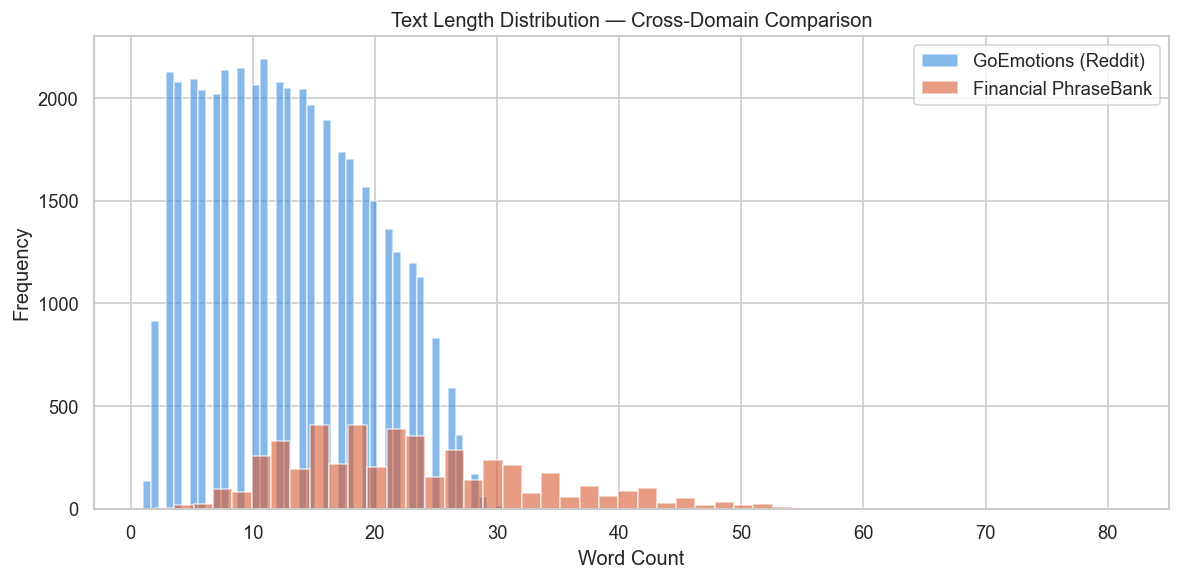

In [19]:
print('Text Length Comparison')
print('=' * 45)
print(f'GoEmotions avg words:           {ge_train["word_count"].mean():.1f}')
print(f'Financial PhraseBank avg words:  {fpb_df["word_count"].mean():.1f}')
print(f'\nGoEmotions median words:        {ge_train["word_count"].median():.0f}')
print(f'Financial PhraseBank median:      {fpb_df["word_count"].median():.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ge_train['word_count'], bins=50, alpha=0.6, label='GoEmotions (Reddit)', color='#378ADD')
ax.hist(fpb_df['word_count'], bins=50, alpha=0.6, label='Financial PhraseBank', color='#D85A30')
ax.set_title('Text Length Distribution — Cross-Domain Comparison')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### D3. Vocabulary overlap analysis.

**critical EDA metric**. Low vocabulary overlap between the general and domain datasets indicates a large domain gap, which predicts that more aggressive adaptation strategies (e.g., DAPT, higher domain weighting) will be needed.

In [20]:
# Build vocabulary sets.
ge_vocab = set(' '.join(ge_train['text'].str.lower()).split())
fpb_vocab = set(' '.join(fpb_df['sentence'].str.lower()).split())
overlap = ge_vocab & fpb_vocab
fpb_only = fpb_vocab - ge_vocab
ge_only = ge_vocab - fpb_vocab

print('Vocabulary Overlap Analysis')
print('=' * 50)
print(f'GoEmotions unique words:           {len(ge_vocab):,}')
print(f'Financial PhraseBank unique words:  {len(fpb_vocab):,}')
print(f'Overlapping words:                  {len(overlap):,}')
print(f'Overlap (% of FPB vocab):           {len(overlap)/len(fpb_vocab)*100:.1f}%')
print(f'FPB-only words (domain-specific):   {len(fpb_only):,}')
print(f'GoEmotions-only words:              {len(ge_only):,}')

Vocabulary Overlap Analysis
GoEmotions unique words:           49,537
Financial PhraseBank unique words:  11,732
Overlapping words:                  4,682
Overlap (% of FPB vocab):           39.9%
FPB-only words (domain-specific):   7,050
GoEmotions-only words:              44,855


Sample domain-specific words (FPB only):
--------------------------------------------------
  ''  '07  '08  '09  '10  '70s  'll  'm  're  've  ($  (business  (cfo),  (ebit)is  (gawker  (hel  (kauhajoki  (nasdaq  (smt)and  (thomson  (tmls)for  +0.6  +1.2  +33  +358  +44  +£lemiste  +£lo  +àkersberga  +àland  +àlandsbanken  +àm+ñl  +ä+ñnekoski  +é  +ó  ,000  ,275  ,754  --------------  ----------------------------------------------------------------------



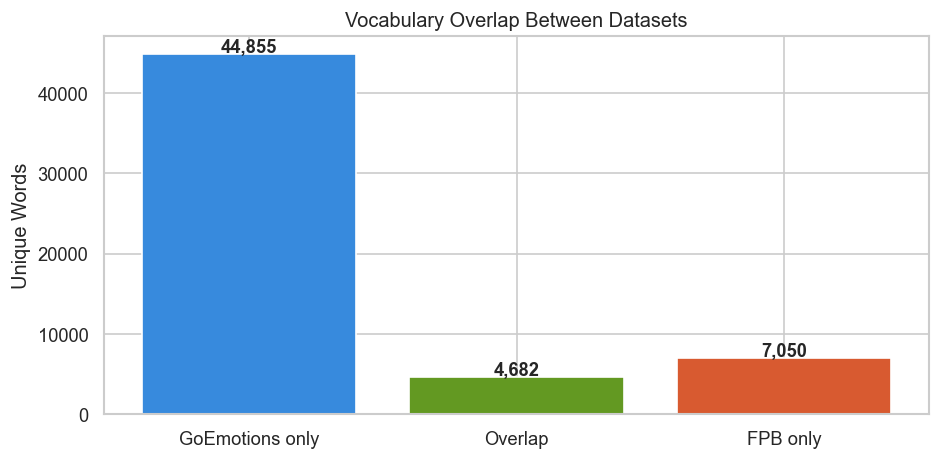

In [21]:
# Show domain-specific words (in Financial PhraseBank but NOT in GoEmotions).
print('Sample domain-specific words (FPB only):')
print('-' * 50)
fpb_only_sorted = sorted(list(fpb_only))
# show a meaningful sample.
for word in fpb_only_sorted[:40]:
    print(f'  {word}', end='')
print('\n')

# Visualise overlap.
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['GoEmotions only', 'Overlap', 'FPB only']
values = [len(ge_only), len(overlap), len(fpb_only)]
colors_v = ['#378ADD', '#639922', '#D85A30']
ax.bar(categories, values, color=colors_v)
ax.set_title('Vocabulary Overlap Between Datasets')
ax.set_ylabel('Unique Words')
for i, v in enumerate(values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part E: Sample Texts.

Let's look at actual examples from both datasets to understand the qualitative difference.

In [22]:
print('FINANCIAL PHRASEBANK — Sample Texts')
print('=' * 60)
for sentiment in ['Positive', 'Neutral', 'Negative']:
    print(f'\n--- {sentiment} ---')
    samples = fpb_df[fpb_df['sentiment'] == sentiment].sample(3, random_state=42)
    for _, row in samples.iterrows():
        text = row['sentence'][:150]
        print(f'  "{text}..."' if len(row['sentence']) > 150 else f'  "{text}"')

FINANCIAL PHRASEBANK — Sample Texts

--- Positive ---
  "The new agreement , which expands a long-established cooperation between the companies , involves the transfer of certain engineering and documentatio..."
  "( ADP News ) - Finnish handling systems provider Cargotec Oyj ( HEL : CGCBV ) announced on Friday it won orders worth EUR 10 million ( USD 13.2 m ) to..."
  "The world 's biggest magazine paper maker said the program to improve efficiency will include closing several of its least competitive mills and would..."

--- Neutral ---
  "The center offers a comprehensive range of device design services spanning from electronics , mechanics and software design to a full range of testing..."
  "AffectoGenimap builds highly customised IT solutions for its customers in Finland and the Baltic countries ."
  "The bank 's leasing arm Nordea Liising ended the year with a profit of 4.4 million euros ."

--- Negative ---
  "The company decided at the end of 2008 to temporarily shut down its 

In [23]:
print('GOEMOTIONS (mapped) — Sample Texts')
print('=' * 60)
for sentiment in ['Bullish', 'Neutral', 'Bearish']:
    print(f'\n--- {sentiment} ---')
    samples = ge_train[ge_train['sentiment_3class'] == sentiment].sample(3, random_state=42)
    for _, row in samples.iterrows():
        text = row['text'][:150]
        print(f'  "{text}..."' if len(row['text']) > 150 else f'  "{text}"')

GOEMOTIONS (mapped) — Sample Texts

--- Bullish ---
  "not quite as cheap but if you already own a decent bike this kit is wel priced to convert"
  "It definitely has the best look to it. Also the best characters. Count [NAME] henchmen are amazing."
  "Great point."

--- Neutral ---
  "And I’ll be there!!!"
  "I understand them.who puts the tp under not over"
  "[NAME] hasn't proved he still has it. Remember Celtic legend [NAME]?"

--- Bearish ---
  "Except I can’t with the mobile app. Reddit doesn’t allow you highlight"
  "I'm worried he's too small. I love his quickness, but sub-170 is scary for a guy that'll be running over the middle."
  "Winnipeg Jets regularly have whiteouts, though I don't believe anyone paints themselves."


---
# Summary:

### Key EDA Findings with 3 class mapping and text stats.

| Metric | GoEmotions | Financial PhraseBank |
|--------|-----------|---------------------|
| Source | Reddit comments | Financial news (LexisNexis) |
| Size | 43k (train) | 4.8k |
| Original labels | 27 emotions + neutral | Positive / Negative / Neutral |
| Mapped labels | Bullish / Bearish / Neutral | Bullish / Bearish / Neutral |
| Avg text length | 12 words | 23 words |
| Register | Informal, slang, emoji | Formal, financial jargon |

### Implications for the Group Project.

1. **Size imbalance** (9x) requires oversampling or weighted training for Model C.
2. **Text length difference** may affect tokenisation and padding strategies.
3. **Low vocabulary overlap** confirms a genuine domain gap - adaptation is needed.
4. **Neutral class dominance** in both datasets needs monitoring during training.
5. **Label mapping decisions** (e.g., where to place `surprise`) should be documented.

### DataFrames available for further analysis:
- `fpb_df` - Financial PhraseBank with sentiment labels and text stats.
- `ge_train` - GoEmotions training set with 3-class mapping and text stats.

---
# Part F: 6-Class Emotion Label Scheme.

> **Note:** Part C above shows the initial 3-class mapping (Bullish/Bearish/Neutral). Following tutor feedback requesting 5–6 emotion labels, Part F below implements the final 6-class scheme used for the project. ( we can remove part E to avoid confusion but in this regard, my individual recommendation is to keep it as it is, as it shows learning and thinking process evolved with the time).

So we now requires **5–6 emotion-based labels** instead of 3. Our unified label scheme:

| Label | Meaning | GoEmotions Source | FPB Source |
|---|---|---|---|
| **Optimism** | Bullish / hopeful | admiration, approval, caring, desire, optimism, pride, relief. | Positive (via pseudo-labelling). |
| **Joy** | Happy / excited | amusement, excitement, gratitude, joy, & love | Positive. (via pseudo-labelling). |
| **Fear** | Risk / uncertainty | fear, nervousness. | Negative (via pseudo-labelling). |
| **Anger** | Frustration / disapproval | anger, annoyance, disapproval, disgust. | Negative (via pseudo-labelling). |
| **Sadness** | Loss / grief | disappointment, embarrassment, grief, remorse, sadness. | Negative (via pseudo-labelling). |
| **Neutral** | No strong emotion | confusion, curiosity, realization, surprise, neutral. | Neutral |

**The challenge:** GoEmotions has 27 labels so we just group them. But Financial PhraseBank only has 3 labels (Positive/Negative/Neutral). To get 6-class labels for FPB, we use **pseudo-labelling**  running a pre-trained GoEmotions emotion classifier over FPB sentences to assign fine-grained emotion labels.

### F1. Define the 6-class mapping for GoEmotions.

In [24]:
# 6-class emotion mapping for GoEmotions.
label_mapping_6class = {
    # Optimism (bullish / hopeful).
    'admiration': 'Optimism', 'approval': 'Optimism', 'caring': 'Optimism',
    'desire': 'Optimism', 'optimism': 'Optimism', 'pride': 'Optimism', 'relief': 'Optimism',

    # Joy (happy / excited).
    'amusement': 'Joy', 'excitement': 'Joy', 'gratitude': 'Joy',
    'joy': 'Joy', 'love': 'Joy',

    # Fear (risk / uncertainty).
    'fear': 'Fear', 'nervousness': 'Fear',

    # Anger (frustration / disapproval).
    'anger': 'Anger', 'annoyance': 'Anger', 'disapproval': 'Anger', 'disgust': 'Anger',

    # Sadness (loss / grief).
    'disappointment': 'Sadness', 'embarrassment': 'Sadness',
    'grief': 'Sadness', 'remorse': 'Sadness', 'sadness': 'Sadness',

    # Neutral.
    'confusion': 'Neutral', 'curiosity': 'Neutral',
    'realization': 'Neutral', 'surprise': 'Neutral', 'neutral': 'Neutral',
}

def map_to_6class(label_ids):
    """Map multi-label GoEmotions to single 6-class label via majority vote."""
    mapped = [label_mapping_6class[emotion_labels[lid]] for lid in label_ids]
    counts = Counter(mapped)
    return counts.most_common(1)[0][0]

ge_train['sentiment_6class'] = ge_train['labels'].apply(map_to_6class)

print('GoEmotions — 6-Class Distribution:')
print(ge_train['sentiment_6class'].value_counts())
print(f'\nPercentages:')
print((ge_train['sentiment_6class'].value_counts(normalize=True) * 100).round(1))

GoEmotions — 6-Class Distribution:
sentiment_6class
Neutral     17318
Optimism     9302
Joy          7624
Anger        5901
Sadness      2647
Fear          618
Name: count, dtype: int64

Percentages:
sentiment_6class
Neutral     39.9
Optimism    21.4
Joy         17.6
Anger       13.6
Sadness      6.1
Fear         1.4
Name: proportion, dtype: float64


### F2. Visualise GoEmotions 6-class distribution.

   ***Color pallet***:  'Optimism': '#639922', 'Joy': '#97C459',
    'Fear': '#E24B4A', 'Anger': '#D85A30',
    'Sadness': '#378ADD', 'Neutral': '#888780'

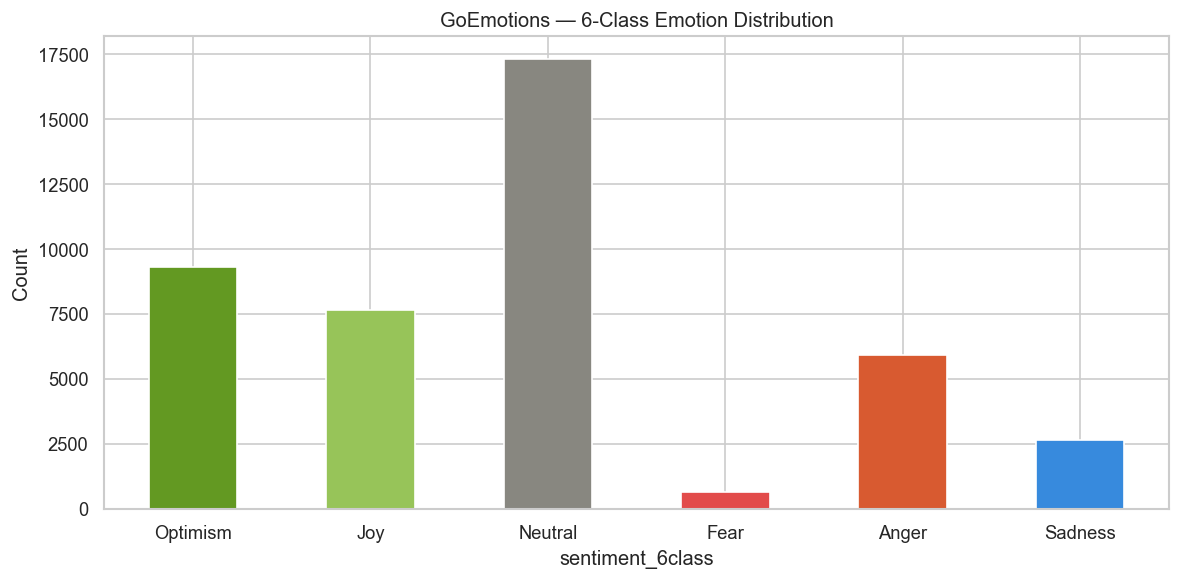

In [25]:
colors_6class = {
    'Optimism': '#639922', 'Joy': '#97C459',
    'Fear': '#E24B4A', 'Anger': '#D85A30',
    'Sadness': '#378ADD', 'Neutral': '#888780'
}
order_6class = ['Optimism', 'Joy', 'Neutral', 'Fear', 'Anger', 'Sadness']

fig, ax = plt.subplots(figsize=(10, 5))
counts = ge_train['sentiment_6class'].value_counts().reindex(order_6class)
counts.plot(kind='bar', ax=ax, color=[colors_6class[s] for s in order_6class])
ax.set_title('GoEmotions — 6-Class Emotion Distribution')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### F3. Pseudo-label Financial PhraseBank with 6 emotion classes.

Financial PhraseBank only has 3 labels (Positive/Negative/Neutral). To create 6-class labels, we use a **pre-trained GoEmotions classifier** from HuggingFace to predict fine-grained emotions for each (FPB) sentences.

This is called **pseudo-labelling** A legitimate technique where a model trained on one dataset assigns labels to another dataset.


In [ ]:
# Install transformers.
!pip install transformers -q
# transformers upgraded for compatibility with latest PyTorch and Hugging Face libraries.
!pip install --upgrade transformers -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# Install pytorch.
!pip install torch torchvision -q

import torch
print(f"PyTorch version: {torch.__version__}")

import sys
print(sys.version)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch version: 2.11.0+cpu
3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]


In [ ]:
import torch
import transformers
transformers.utils.import_utils._torch_available = True
import sys
sys.modules['torch'] = torch

from transformers import pipeline
# Load a pre-trained GoEmotions emotion classifier.
# This model was trained on GoEmotions and predicts emotion labels.

emotion_classifier = pipeline(
    'text-classification',
    model='SamLowe/roberta-base-go_emotions',
    top_k=3,  # get top 3 predictions per sentence.
    truncation=True,
    device=-1
)

# Test on a sample financial sentence.

test_sentence = "Net sales decreased 20.4% to EUR 68.7 mn"
result = emotion_classifier(test_sentence)
print(f'Input:  "{test_sentence}"')
print(f'Output: {result}')

C:\Users\vikra\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vikra\.cache\huggingface\hub\models--SamLowe--roberta-base-go_emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6710.09it/s]
RobertaForSequenceClass

Input:  "Net sales decreased 20.4% to EUR 68.7 mn"
Output: [[{'label': 'disappointment', 'score': 0.7035447955131531}, {'label': 'sadness', 'score': 0.28836554288864136}, {'label': 'neutral', 'score': 0.18513870239257812}]]
